# DDoS Attack Detector — BiLSTM Training Notebook

**Model:** Bidirectional LSTM (PyTorch)
**Task:** Binary classification — `Benign (0)` vs `Attack (1)`

| Dataset | Archive | Role |
|---|---|---|
| CIC-IDS-2018 | `archive (1)` — 10 CSV files | Training |
| CIC-DDoS-2019 | `archive (2)` — 18 CSV files | Training |
| Multi-class flows | `archive (4)/csv/data.csv` | Testing (via FastAPI) |

**Outputs saved to `./saved_model/`:**
- `bilstm_ddos.pt` — trained model weights
- `scaler.pkl` — fitted StandardScaler
- `label_encoder.pkl` — feature list + metadata

---
> Run cells top-to-bottom. Adjust `ROWS_PER_FILE` in Section 2 to control memory usage.


## Section 1 — Import Required Libraries

In [6]:
import os, sys, glob, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, f1_score,
)

# Add project root to path so utils.py is importable
sys.path.insert(0, os.path.abspath("..") if os.path.basename(os.getcwd()) != "DDos Attack Detector" else ".")
from utils import FEATURE_COLS, normalize_columns, get_label, clean_features, create_sequences

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch     : {torch.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"Device      : {DEVICE}")


PyTorch     : 2.6.0+cu124
NumPy       : 1.26.4
Pandas      : 2.2.0
scikit-learn: 1.8.0
Device      : cuda


## Section 2 — Configuration & Data Loading

### Configuration  
Adjust `ROWS_PER_FILE` to control RAM usage:
- `150_000` → safe for 16 GB RAM (~4 M rows total)
- `500_000` → good for 32 GB RAM or GPU training
- `None` → load every row (requires 64+ GB)

In [7]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR     = os.path.abspath(".")
ARCHIVE1_DIR = os.path.join(BASE_DIR, "archive (1)")
ARCHIVE2_DIR = os.path.join(BASE_DIR, "archive (2)")
MODEL_DIR    = os.path.join(BASE_DIR, "saved_model")
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
ROWS_PER_FILE = 150_000     # rows sampled per CSV  (None = full file)
SEQUENCE_LEN  = 10          # timesteps per BiLSTM window
BATCH_SIZE    = 512
EPOCHS        = 30
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.15
SEED          = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("Configuration set.")
print(f"  BASE_DIR     : {BASE_DIR}")
print(f"  MODEL_DIR    : {MODEL_DIR}")
print(f"  ROWS_PER_FILE: {ROWS_PER_FILE:,}" if ROWS_PER_FILE else "  ROWS_PER_FILE: ALL")
print(f"  SEQUENCE_LEN : {SEQUENCE_LEN}")
print(f"  BATCH_SIZE   : {BATCH_SIZE}")
print(f"  EPOCHS       : {EPOCHS}")


Configuration set.
  BASE_DIR     : c:\Users\darne\Desktop\AI Projects\DDos Attack Detector
  MODEL_DIR    : c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model
  ROWS_PER_FILE: 150,000
  SEQUENCE_LEN : 10
  BATCH_SIZE   : 512
  EPOCHS       : 30


In [8]:
# ── Discover all training CSV files ───────────────────────────────────────────
csv_paths = sorted(
    glob.glob(os.path.join(ARCHIVE1_DIR, "*.csv")) +
    glob.glob(os.path.join(ARCHIVE2_DIR, "**", "*.csv"), recursive=True)
)

print(f"Found {len(csv_paths)} training CSVs:\n")
total_gb = 0
rows_data = []
for p in csv_paths:
    size_mb = os.path.getsize(p) / 1e6
    total_gb += size_mb / 1000
    archive = "archive (1)" if "archive (1)" in p else "archive (2)"
    rows_data.append({"Archive": archive, "File": os.path.basename(p), "Size (MB)": round(size_mb, 1)})

df_files = pd.DataFrame(rows_data)
display(df_files.style.bar(subset=["Size (MB)"], color="#6366f1").format({"Size (MB)": "{:.1f}"}))
print(f"\nTotal raw data: {total_gb:.1f} GB")


Found 28 training CSVs:



,Archive,File,Size (MB)
0,archive (1),02-14-2018.csv,358.2
1,archive (1),02-15-2018.csv,375.9
2,archive (1),02-16-2018.csv,333.7
3,archive (1),02-20-2018.csv,4054.9
4,archive (1),02-21-2018.csv,328.9
5,archive (1),02-22-2018.csv,382.6
6,archive (1),02-23-2018.csv,382.8
7,archive (1),02-28-2018.csv,209.2
8,archive (1),03-01-2018.csv,107.8
9,archive (1),03-02-2018.csv,352.4



Total raw data: 37.9 GB


In [9]:
# ── Load & preprocess all CSVs ────────────────────────────────────────────────
def load_single_csv(path, nrows):
    try:
        df = pd.read_csv(path, nrows=nrows, encoding="utf-8",
                         on_bad_lines="skip", low_memory=False)
        df = normalize_columns(df)
        for col in FEATURE_COLS:
            if col not in df.columns:
                df[col] = 0.0
        df = clean_features(df)
        df["binary_label"] = get_label(df)
        return df[FEATURE_COLS + ["binary_label"]]
    except Exception as e:
        print(f"  ⚠  Skipped {os.path.basename(path)}: {e}")
        return None

X_parts, y_parts = [], []
label_counts = {"Benign": 0, "Attack": 0}

for i, path in enumerate(csv_paths, 1):
    fname = os.path.relpath(path, BASE_DIR)
    print(f"[{i:2d}/{len(csv_paths)}] {fname}", end=" … ", flush=True)
    df = load_single_csv(path, ROWS_PER_FILE)
    if df is None:
        continue
    y = df["binary_label"].values.astype(np.int8)
    X = df[FEATURE_COLS].values.astype(np.float32)
    X_parts.append(X); y_parts.append(y)
    b, a = (y==0).sum(), (y==1).sum()
    label_counts["Benign"] += b; label_counts["Attack"] += a
    print(f"rows={len(df):,}  benign={b:,}  attack={a:,}")

X_raw = np.concatenate(X_parts); y_raw = np.concatenate(y_parts)
del X_parts, y_parts

print(f"\nTotal samples : {len(X_raw):,}")
print(f"  Benign      : {label_counts['Benign']:,}")
print(f"  Attack      : {label_counts['Attack']:,}")
print(f"  Attack ratio: {label_counts['Attack']/len(y_raw)*100:.1f}%")


[ 1/28] archive (1)\02-14-2018.csv … rows=150,000  benign=126  attack=149,874
[ 2/28] archive (1)\02-15-2018.csv … rows=150,000  benign=97,502  attack=52,498
[ 3/28] archive (1)\02-16-2018.csv … rows=150,000  benign=15,493  attack=134,507
[ 4/28] archive (1)\02-20-2018.csv … rows=150,000  benign=91  attack=149,909
[ 5/28] archive (1)\02-21-2018.csv … rows=150,000  benign=2,212  attack=147,788
[ 6/28] archive (1)\02-22-2018.csv … rows=150,000  benign=149,638  attack=362
[ 7/28] archive (1)\02-23-2018.csv … rows=150,000  benign=149,434  attack=566
[ 8/28] archive (1)\02-28-2018.csv … rows=150,000  benign=149,994  attack=6
[ 9/28] archive (1)\03-01-2018.csv … rows=150,000  benign=117,644  attack=32,356
[10/28] archive (1)\03-02-2018.csv … rows=150,000  benign=25,249  attack=124,751
[11/28] archive (2)\CSV-01-12\01-12\DrDoS_DNS.csv … rows=150,000  benign=1,743  attack=148,257
[12/28] archive (2)\CSV-01-12\01-12\DrDoS_LDAP.csv … rows=150,000  benign=37  attack=149,963
[13/28] archive (2)\CS

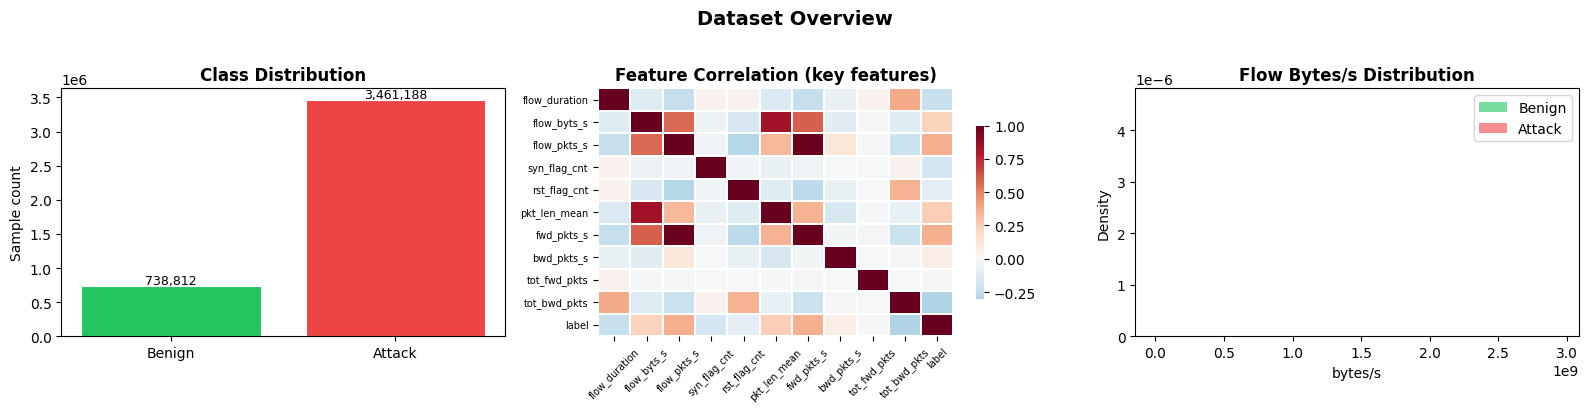

In [10]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Class distribution
axes[0].bar(["Benign", "Attack"],
            [label_counts["Benign"], label_counts["Attack"]],
            color=["#22c55e", "#ef4444"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Sample count")
for bar, v in zip(axes[0].patches, [label_counts["Benign"], label_counts["Attack"]]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(label_counts.values())*0.01,
                 f"{v:,}", ha="center", fontsize=9)

# 2. Feature correlation heatmap (sample 5 000 rows)
sample_idx = np.random.choice(len(X_raw), min(5000, len(X_raw)), replace=False)
key_feats = ["flow_duration", "flow_byts_s", "flow_pkts_s",
             "syn_flag_cnt", "rst_flag_cnt", "pkt_len_mean",
             "fwd_pkts_s", "bwd_pkts_s", "tot_fwd_pkts", "tot_bwd_pkts"]
feat_idx = [FEATURE_COLS.index(f) for f in key_feats]
corr_df  = pd.DataFrame(X_raw[np.ix_(sample_idx, feat_idx)], columns=key_feats)
corr_df["label"] = y_raw[sample_idx]
sns.heatmap(corr_df.corr(), ax=axes[1], cmap="RdBu_r", center=0,
            linewidths=0.3, annot=False, cbar_kws={"shrink": 0.7})
axes[1].set_title("Feature Correlation (key features)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)
axes[1].tick_params(axis="y", rotation=0, labelsize=7)

# 3. Flow bytes/s distribution per class
for cls, colour, name in [(0, "#22c55e", "Benign"), (1, "#ef4444", "Attack")]:
    vals = X_raw[y_raw==cls, FEATURE_COLS.index("flow_byts_s")]
    vals = vals[np.isfinite(vals) & (vals > 0) & (vals < np.percentile(vals[vals>0], 99))]
    axes[2].hist(vals, bins=60, alpha=0.6, color=colour, label=name, density=True)
axes[2].set_title("Flow Bytes/s Distribution", fontweight="bold")
axes[2].set_xlabel("bytes/s"); axes[2].set_ylabel("Density"); axes[2].legend()

plt.suptitle("Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# ── Scaling & Sequence Creation ───────────────────────────────────────────────

# Shuffle before splitting
idx = np.random.permutation(len(X_raw))
X_raw, y_raw = X_raw[idx], y_raw[idx]

# Fit StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
del X_raw
print("StandardScaler fitted.")

# Create non-overlapping sequences of length SEQUENCE_LEN
X_seq, y_seq = create_sequences(X_scaled, y_raw, SEQUENCE_LEN)
del X_scaled, y_raw
print(f"Sequence shape : X={X_seq.shape}  y={y_seq.shape}")

# Train / Validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_seq, y_seq, test_size=VAL_SPLIT, random_state=SEED, stratify=y_seq
)
del X_seq, y_seq
print(f"Train set      : {X_tr.shape}")
print(f"Validation set : {X_val.shape}")

# Class weights for imbalanced data
classes = np.unique(y_tr)
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weight_tensor = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
print(f"\nClass weights: { {int(c): round(float(w),4) for c,w in zip(classes,cw)} }")

# Build PyTorch DataLoaders
train_ds = TensorDataset(
    torch.from_numpy(X_tr),
    torch.from_numpy(y_tr.astype(np.int64))
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val.astype(np.int64))
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=(DEVICE.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE.type=="cuda"))
print(f"Train batches  : {len(train_loader):,}")
print(f"Val batches    : {len(val_loader):,}")


StandardScaler fitted.
Sequence shape : X=(420000, 10, 66)  y=(420000,)
Train set      : (357000, 10, 66)
Validation set : (63000, 10, 66)

Class weights: {0: 2.8424, 1: 0.6067}
Train batches  : 698
Val batches    : 124


## Section 3 — Define the Model Architecture

```
Input  (SEQUENCE_LEN × 66 features)
   ↓
BiLSTM — 64 units (return_sequences=True)  + dropout 0.2
   ↓
BiLSTM — 32 units (return_sequences=False) + dropout 0.2
   ↓
Dense  — 64 units, ReLU  +  Dropout 0.3
   ↓
Dense  — 2 units, Softmax   → [P(Benign), P(Attack)]
```


In [12]:
n_features = X_tr.shape[2]   # 64 canonical features


class BiLSTMDetector(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        self.bilstm1 = nn.LSTM(
            input_size=n_features, hidden_size=64, num_layers=1,
            batch_first=True, bidirectional=True, dropout=0.0
        )
        self.drop1 = nn.Dropout(0.2)
        self.bilstm2 = nn.LSTM(
            input_size=128, hidden_size=32, num_layers=1,
            batch_first=True, bidirectional=True, dropout=0.0
        )
        self.drop2   = nn.Dropout(0.2)
        self.dense   = nn.Linear(64, 64)
        self.relu    = nn.ReLU()
        self.drop3   = nn.Dropout(0.3)
        self.output  = nn.Linear(64, 2)

    def forward(self, x):                     # x: (B, seq, features)
        out, _ = self.bilstm1(x)              # (B, seq, 128)
        out     = self.drop1(out)
        out, _ = self.bilstm2(out)            # (B, seq, 64)
        out     = self.drop2(out[:, -1, :])   # last timestep → (B, 64)
        out     = self.drop3(self.relu(self.dense(out)))
        return self.output(out)               # (B, 2)  — raw logits


model = BiLSTMDetector(n_features).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"BiLSTM model on {DEVICE}")
print(f"Total parameters: {total_params:,}")
print(model)


BiLSTM model on cuda
Total parameters: 113,346
BiLSTMDetector(
  (bilstm1): LSTM(66, 64, batch_first=True, bidirectional=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (bilstm2): LSTM(128, 32, batch_first=True, bidirectional=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (dense): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (drop3): Dropout(p=0.3, inplace=False)
  (output): Linear(in_features=64, out_features=2, bias=True)
)


## Section 4 — Train the Model

Callbacks used:
- **EarlyStopping** — stops if `val_loss` doesn't improve for 5 epochs, restores best weights
- **ReduceLROnPlateau** — halves LR after 3 stagnant epochs
- **ModelCheckpoint** — saves best checkpoint to `saved_model/bilstm_ddos.keras`

In [13]:
criterion  = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer  = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6, verbose=True
)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0
EARLY_STOP_PATIENCE = 5
best_model_path = os.path.join(MODEL_DIR, "bilstm_ddos.pt")

print(f"Training for up to {EPOCHS} epochs | batch={BATCH_SIZE} | lr={LEARNING_RATE}")
print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}\n")

for epoch in range(1, EPOCHS + 1):
    # ── train ──────────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item() * len(yb)
        tr_correct += (logits.argmax(1) == yb).sum().item()
        tr_total   += len(yb)

    # ── validate ────────────────────────────────────────────────────────────
    model.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(Xb)
            loss    = criterion(logits, yb)
            vl_loss    += loss.item() * len(yb)
            vl_correct += (logits.argmax(1) == yb).sum().item()
            vl_total   += len(yb)

    tr_loss /= tr_total;  vl_loss /= vl_total
    tr_acc   = tr_correct / tr_total
    vl_acc   = vl_correct / vl_total
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    scheduler.step(vl_loss)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss={tr_loss:.4f}  acc={tr_acc*100:.2f}%  |  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc*100:.2f}%")

    # ── early stopping + checkpoint ─────────────────────────────────────────
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ checkpoint saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

# Restore best weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print("\nTraining complete. Best weights restored.")


Training for up to 30 epochs | batch=512 | lr=0.001
Train batches: 698  |  Val batches: 124

Epoch   1/30  loss=0.1293  acc=94.47%  |  val_loss=0.0732  val_acc=97.03%
  ✓ checkpoint saved (val_loss=0.0732)
Epoch   2/30  loss=0.0697  acc=97.66%  |  val_loss=0.0606  val_acc=97.83%
  ✓ checkpoint saved (val_loss=0.0606)
Epoch   3/30  loss=0.0625  acc=97.89%  |  val_loss=0.0564  val_acc=98.02%
  ✓ checkpoint saved (val_loss=0.0564)
Epoch   4/30  loss=0.0582  acc=98.03%  |  val_loss=0.0527  val_acc=98.14%
  ✓ checkpoint saved (val_loss=0.0527)
Epoch   5/30  loss=0.0561  acc=98.11%  |  val_loss=0.0512  val_acc=98.14%
  ✓ checkpoint saved (val_loss=0.0512)
Epoch   6/30  loss=0.0539  acc=98.16%  |  val_loss=0.0521  val_acc=98.21%
Epoch   7/30  loss=0.0533  acc=98.18%  |  val_loss=0.0496  val_acc=98.18%
  ✓ checkpoint saved (val_loss=0.0496)
Epoch   8/30  loss=0.0520  acc=98.20%  |  val_loss=0.0494  val_acc=98.27%
  ✓ checkpoint saved (val_loss=0.0494)
Epoch   9/30  loss=0.0510  acc=98.21%  |  

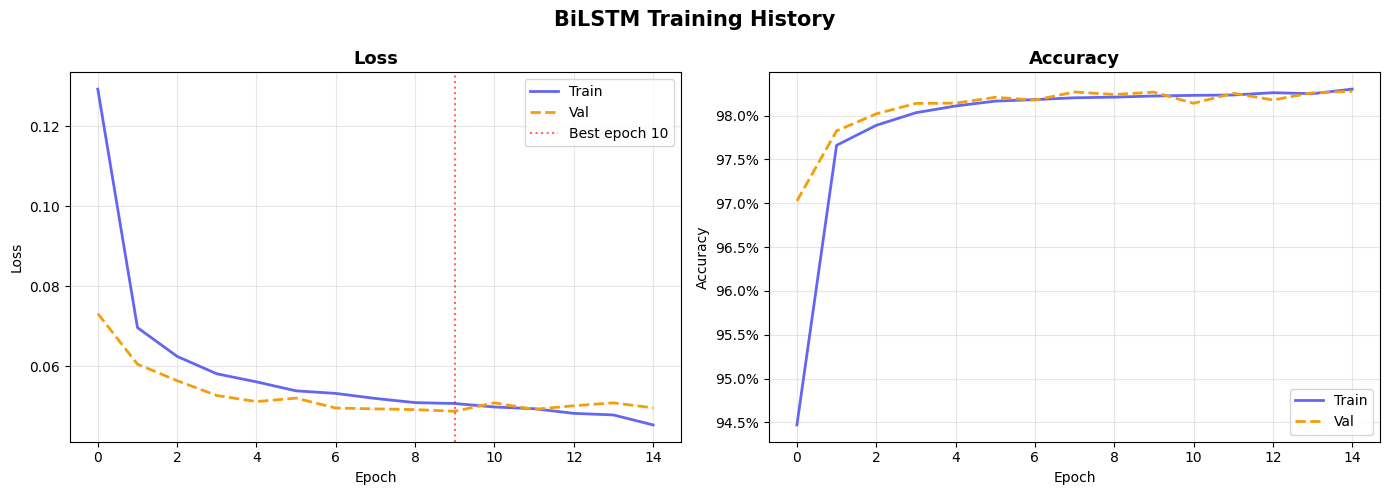

Plot saved → c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model\training_history.png


In [14]:
# ── Training History Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train", color="#6366f1", linewidth=2)
axes[0].plot(history["val_loss"],   label="Val",   color="#f59e0b", linewidth=2, linestyle="--")
axes[0].set_title("Loss", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
best_ep = int(np.argmin(history["val_loss"]))
axes[0].axvline(best_ep, color="red", linestyle=":", alpha=0.6, label=f"Best epoch {best_ep+1}")
axes[0].legend()

# Accuracy
axes[1].plot(history["train_acc"], label="Train", color="#6366f1", linewidth=2)
axes[1].plot(history["val_acc"],   label="Val",   color="#f59e0b", linewidth=2, linestyle="--")
axes[1].set_title("Accuracy", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.1f}%"))

plt.suptitle("BiLSTM Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "training_history.png"), dpi=130, bbox_inches="tight")
plt.show()
print(f"Plot saved → {os.path.join(MODEL_DIR, 'training_history.png')}")


## Section 5 — Evaluate the Model

Evaluate on the held-out validation set and display confusion matrix + classification report.

In [15]:
CLASS_NAMES = ["Benign", "Attack"]

# Predict on validation set
model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        logits = model(Xb.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(yb.numpy())

preds      = np.array(all_preds)
attack_prob = np.array(all_probs)
y_val_np   = np.array(all_labels)

acc  = accuracy_score(y_val_np, preds)
f1   = f1_score(y_val_np, preds, average="weighted", zero_division=0)
try:
    auc = roc_auc_score(y_val_np, attack_prob)
except Exception:
    auc = float("nan")

print("=" * 50)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  F1 Score  : {f1:.4f}  (weighted)")
print(f"  ROC-AUC   : {auc:.4f}")
print("=" * 50)
print(classification_report(y_val_np, preds, target_names=CLASS_NAMES, digits=4))


  Accuracy  : 98.27%
  F1 Score  : 0.9830  (weighted)
  ROC-AUC   : 0.9964
              precision    recall  f1-score   support

      Benign     0.9139    0.9952    0.9528     11082
      Attack     0.9990    0.9800    0.9894     51918

    accuracy                         0.9827     63000
   macro avg     0.9564    0.9876    0.9711     63000
weighted avg     0.9840    0.9827    0.9830     63000



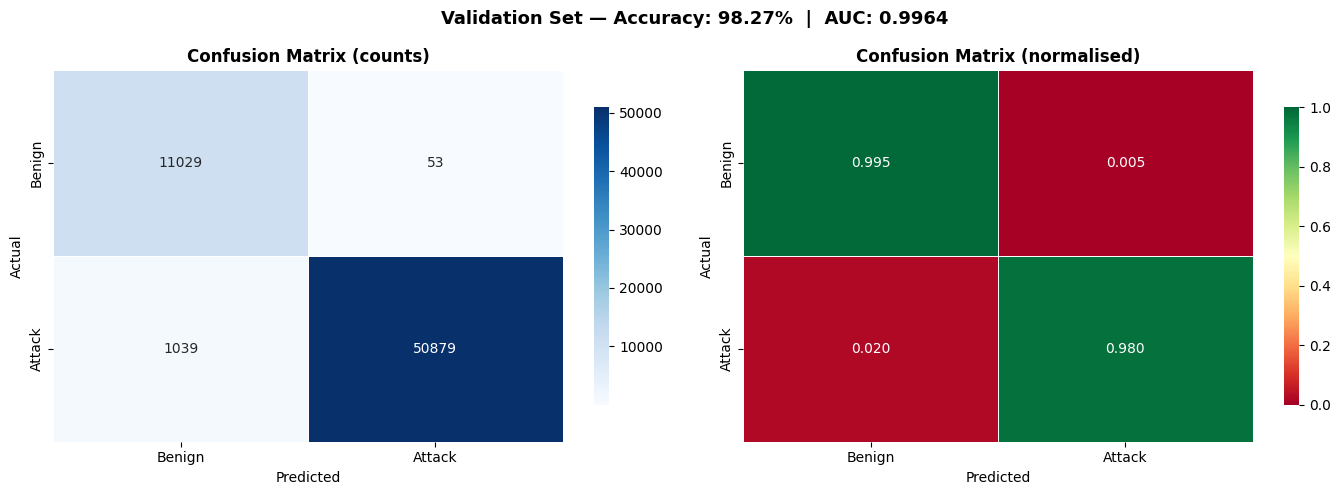

In [16]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_val_np, preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("Confusion Matrix (counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="RdYlGn",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Confusion Matrix (normalised)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle(f"Validation Set — Accuracy: {acc*100:.2f}%  |  AUC: {auc:.4f}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "val_confusion_matrix.png"), dpi=130, bbox_inches="tight")
plt.show()


## Section 6 — Save the Model

Save everything needed by the **FastAPI server** (`app.py`) to `./saved_model/`:

| File | Purpose |
|---|---|
| `bilstm_ddos.keras` | Full model weights + architecture |
| `scaler.pkl` | Fitted `StandardScaler` for feature normalisation |
| `label_encoder.pkl` | Feature list, class names, sequence length |

In [17]:
# ── Save scaler ───────────────────────────────────────────────────────────────
scaler_path = os.path.join(MODEL_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"[1/3] Scaler saved       → {scaler_path}")

# ── Save metadata ─────────────────────────────────────────────────────────────
meta = {
    "feature_cols" : FEATURE_COLS,
    "class_names"  : CLASS_NAMES,
    "seq_len"      : SEQUENCE_LEN,
    "n_features"   : n_features,
    "val_accuracy" : round(acc * 100, 4),
    "val_f1"       : round(f1, 4),
    "val_auc"      : round(auc, 4) if not np.isnan(auc) else None,
}
meta_path = os.path.join(MODEL_DIR, "label_encoder.pkl")
joblib.dump(meta, meta_path)
print(f"[2/3] Metadata saved     → {meta_path}")

# ── The model weights were already saved by the checkpoint callback ────────────
model_path = os.path.join(MODEL_DIR, "bilstm_ddos.pt")
print(f"[3/3] Model weights      → {model_path}")
print(f"      Size: {os.path.getsize(model_path)/1e6:.2f} MB")

print("\n✅  All artefacts saved.  You can now start the FastAPI server:")
print("    python -m uvicorn app:app --host 0.0.0.0 --port 8000")


[1/3] Scaler saved       → c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model\scaler.pkl
[2/3] Metadata saved     → c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model\label_encoder.pkl
[3/3] Model weights      → c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model\bilstm_ddos.pt
      Size: 0.46 MB

✅  All artefacts saved.  You can now start the FastAPI server:
    python -m uvicorn app:app --host 0.0.0.0 --port 8000


In [18]:
# ── Verify saved model loads back correctly ───────────────────────────────────
print("Verifying saved model …")
model_check = BiLSTMDetector(n_features).to(DEVICE)
model_check.load_state_dict(torch.load(model_path, map_location=DEVICE))
model_check.eval()

dummy = torch.zeros(1, SEQUENCE_LEN, n_features, device=DEVICE)
with torch.no_grad():
    out = torch.softmax(model_check(dummy), dim=1).cpu().numpy()
print(f"  Model output shape : {out.shape}")
print(f"  Dummy prediction   : Benign={out[0,0]:.4f}  Attack={out[0,1]:.4f}")
print(f"\n✅  Model verified.  Artefacts in: {MODEL_DIR}")
print("\nSaved files:")
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    print(f"  {fname:35s}  {os.path.getsize(fpath)/1e6:.2f} MB")


Verifying saved model …
  Model output shape : (1, 2)
  Dummy prediction   : Benign=0.0017  Attack=0.9983

✅  Model verified.  Artefacts in: c:\Users\darne\Desktop\AI Projects\DDos Attack Detector\saved_model

Saved files:
  bilstm_ddos.pt                       0.46 MB
  label_encoder.pkl                    0.00 MB
  scaler.pkl                           0.00 MB
  training_history.png                 0.08 MB
  val_confusion_matrix.png             0.05 MB
